<a href="https://colab.research.google.com/github/saraalmazroa/-IT326-DataMining-Project-/blob/main/Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Data Selection


## Project Goal

This project aims to classify bank loan applicants as good or bad credit
risks based on their personal and financial attributes. Classification
models will predict each applicant's risk, while clustering will group
applicants with similar characteristics.

## Dataset Source

Dataset: German Credit Risk
Source: Kaggle, originally based on the Statlog (German Credit Data)
dataset from the UCI Machine Learning Repository.

URL: https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk

**Age** – Age of the applicant (Numeric)

**Sex** – Gender of the applicant: male/female (Categorical)

**Job** – Job skill level, from 0 (unskilled) to 3 (highly qualified) (Categorical, encoded)

**Housing** – Housing type: own / rent / free (Categorical)

**Saving accounts** – Savings account level: little / moderate / quite rich / rich (Categorical)

**Checking account** – Checking account level: little / moderate / rich (Categorical)

**Credit amount** – Requested credit amount (Numeric)

**Duration** – Credit duration in months (Numeric)

**Purpose** – Purpose of the credit, e.g. car, education, furniture (Categorical)

**Risk** – Credit risk, target class: good / bad (Categorical – target)

# Phase 1: Data Selection
## German Credit Risk Dataset

### Load the Dataset
This cell loads the German Credit dataset directly from our GitHub repository using pandas. Reading the file this way keeps the notebook self-contained and reproducible, so anyone opening it can run the code without manually downloading the file.

In [111]:
import pandas as pd

url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)

## Dataset Description

**Number of records (rows):** 1000


**Number of attributes (columns):** 11

**Class Label:** Risk

**Attribute data types:**
int64: 5 attributes

object: 6 attributes

Note:
This dataset consists of 1000 rows and 11 columns.
It contains 5 numerical attributes (int64) representing measurable values, and 6 categorical/text attributes (object) representing descriptive information.

## Number and Data Types of Attributes
Counts the attributes (excluding the class label) and shows each column's
data type, to decide how to preprocess each one later.

In [112]:
attributes_summary = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values
})

print("\nColumns and their data types:\n")
print(attributes_summary)

print(f"\nTotal number of attributes: {df.shape[1]}")


Columns and their data types:

              Column    Type
0         Unnamed: 0   int64
1                Age   int64
2                Sex  object
3                Job   int64
4            Housing  object
5    Saving accounts  object
6   Checking account  object
7      Credit amount   int64
8           Duration   int64
9            Purpose  object
10              Risk  object

Total number of attributes: 11


In [113]:
print(f"Number of attributes:  {len(df.columns)}")
df.dtypes

Number of attributes:  11


,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


In [114]:
print(f"Number of instances: {df.shape[0]}")
df.dtypes

Number of instances: 1000


,0
Unnamed: 0,int64
Age,int64
Sex,object
Job,int64
Housing,object
Saving accounts,object
Checking account,object
Credit amount,int64
Duration,int64
Purpose,object


## Class Attribute and Instance Count per Label
The class (target) attribute is Risk, which represents the credit risk
of each applicant.

It has two possible values: good and bad.
Out of **1000** instances, **700** are classified as **good** and **300** as **bad**.

In [115]:
target_col='Risk'
print("The class lable is:",target_col)
print("The class lable Values:",df[target_col].unique())


The class lable is: Risk
The class lable Values: ['good' 'bad']


In [116]:
print("Number of customers in each Risk category:")
print(df[target_col].value_counts())

Number of customers in each Risk category:
Risk
good    700
bad     300
Name: count, dtype: int64


### Sample of the Raw Dataset
Displays the first 5 rows from the dataset.


In [117]:
print("Sample of the raw dataset:")
df.head()  #first 5 rows

Sample of the raw dataset:


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


# Phase 2

# 1-Data Analysis

## Five Number Summary, Boxplots & Outlier Detection

In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
# 1) Five Number Summary
numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']
print("Five Number Summary:")
df[numeric_cols].describe()

Five Number Summary:


,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


# Statistical Summary of the Numeric Attributes

Age: Values span from 19 to 75 years, clustering mainly around 27–42 (median ≈ 33, mean ≈ 35.5). A standard deviation of roughly 11 points to a moderate spread, with the applicant pool skewing toward middle age.

Job: Although coded numerically (0–3), this attribute actually represents categories of job type rather than a true numeric quantity. Given this, a bar chart is a more suitable way to visualize it than the boxplot used for the others.

Credit amount: Loan values range widely, from 250 up to 18,424, with the bulk falling between roughly 1,360 and 3,970 (median ≈ 2,320, mean ≈ 3,271). The large standard deviation (~2,820) reflects this variability, driven by a mix of modest and very large loans.

Duration: Repayment periods run from 4 to 72 months, centered around a median of 18 and a mean near 21. Most loans fall in the 12–24 month range, though a subset extends well beyond that.

*Note: Job is excluded from the outlier analysis, since it is a categorical variable represented with numeric codes rather than a genuinely continuous attribute.*

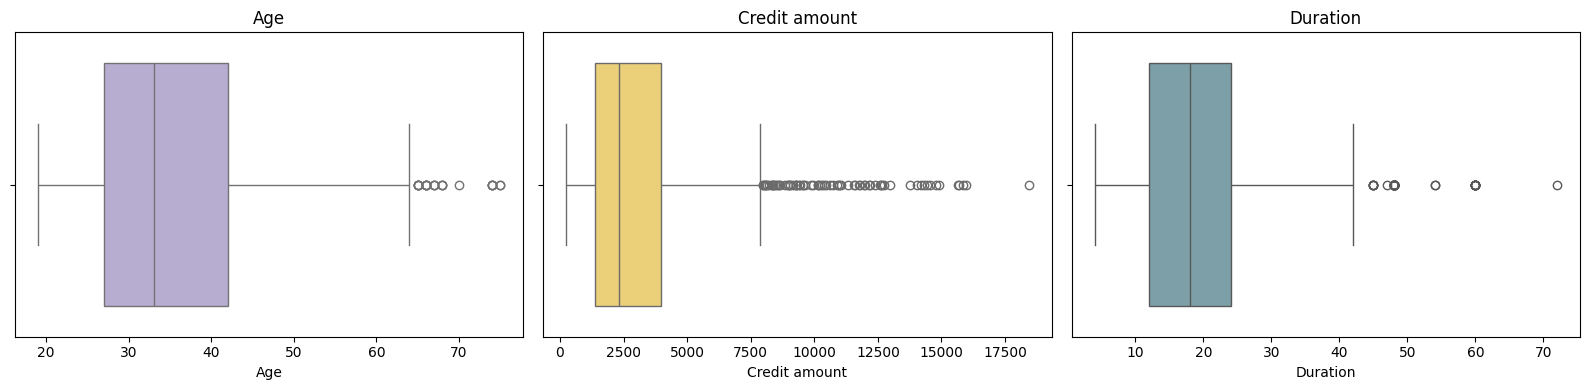

In [120]:
# 2) Boxplot for each numeric column
numeric_colums = ['Age', 'Credit amount', 'Duration']
colors = ['#B4A7D6', '#FFD966', '#76A5AF']
plt.figure(figsize=(16,4))
for i, col in enumerate(numeric_colums, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(x=df[col], color=colors[i-1])
  plt.title(f'{col}')

plt.tight_layout()
plt.show()

#Age Boxplot
Most applicants are between 27–42 years old (median ≈ 33), with 23 outliers above 64.5. The moderate spread suggests normalization may help later, especially for distance-based algorithms.

# Credit Amount Boxplot
Strongly right-skewed — most loans are under ~4,000, but 72 outliers reach up to 18,424. This indicates the need for transformation (e.g., log) to prevent large values from dominating the analysis.

# *Duration Boxplot*
Similar right skew: most durations are 12–24 months, but 70 outliers extend to 72 months. This also points to needing normalization/transformation.

In [121]:
# 3) Outlier Detection using the IQR method
numeric_cols = ['Age', 'Credit amount', 'Duration']

results = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    results.append({
        'Attribute': col,
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outliers Count': len(outliers),
        'Outliers %': round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(results)
print("Outlier Detection Summary (IQR method)")
display(outlier_df)

Outlier Detection Summary (IQR method)


,Attribute,Lower Bound,Upper Bound,Outliers Count,Outliers %
0,Age,4.50,64.50,23,2.3
1,Credit amount,-2544.62,7882.38,72,7.2
2,Duration,-6.00,42.00,70,7.0


# Outlier Analysis Summary
Age: 2.3% outliers — minimal impact.

Credit amount: 7.2% outliers — consistent with its right-skewed distribution.

Duration: 7% outliers — also right-skewed.
All percentages are under 10%, so records will be kept and handled later via normalization/transformation rather than removed.

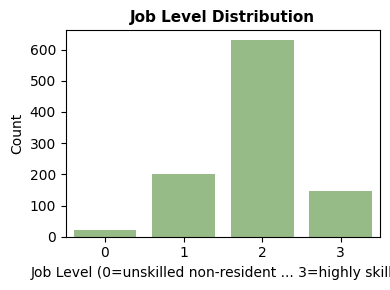

In [122]:
# 4) Job Distribution (Bar Chart) - Categorical Attribute
plt.figure(figsize=(4, 3))
sns.countplot(x=df['Job'], color='#93C47D')
plt.title('Job Level Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Job Level (0=unskilled non-resident ... 3=highly skilled)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most applicants fall into category 2, with far fewer in 0, 1, and 3. This confirms Job is categorical, not continuous — it may need encoding later, and explains why IQR gave meaningless results for it.